In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from chemevo import evolution as evo

params = {
   'axes.labelsize': 15,
   'font.size': 15,
   'legend.fontsize': 10,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 15,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)

colors = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#F0E442"]

In [3]:
#No metallicity dependance
t_array = np.linspace(0.001,14,int(1e3))
m_g_array_const = np.ones(len(t_array))
tau_sfh = 6 #Gyrs
m_g_array_exp = 1 * np.exp(-t_array/tau_sfh)
gal1 = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_exp)
Z_Fe_1 = gal1.compute_z_Fe()
Z_O_1 = gal1.compute_z_O()
eq_Fe_1 = gal1.analytic_eq_Fe(SFR_function="exponential")

# 1) Outline

$ K_{Mn}^{Ia} = K_{Mn}^{Ia}(Z_{solar} F(Z_O/Z_{O, solar})) $

# 1.1) Starting with $K_{Mn}^{Ia}(Z_{solar})$

In [4]:
#1. What is Z_Mn_solar?
#Starint with Magg et al. 2022
Z_Fe_solar = 0.0012
Z_O_solar = 0.0056
A_Mn = 5.52
mass_Mn = 54.94

def get_solar_abundance_from_A(A, mass):
    log_Z_solar = A - 12 + np.log10(mass) + np.log10(0.71)
    Z_solar = 10**log_Z_solar
    return Z_solar

Z_Mn_solar = get_solar_abundance_from_A(A_Mn, mass_Mn)
print("Z_{Mn,solar} = ", Z_Mn_solar)

Z_{Mn,solar} =  1.2916564108120031e-05


In [5]:
#2. Now we need f_Ia_Mn and f_Ia_Fe

def get_f_Ia(R_Ia_X):
    return 1 - (1 + R_Ia_X)**(-1)

f_Ia_Fe = get_f_Ia(1)
f_Ia_Mn = get_f_Ia(1.97)
print(f"f_Ia_Fe = {f_Ia_Fe} and f_Ia_Mn = {f_Ia_Mn}")

f_Ia_Fe = 0.5 and f_Ia_Mn = 0.6632996632996633


In [6]:
#3. Now let's put it all together
K_Fe_Ia = 0.77 #WAF2017

mass_ratio_solar_Mn_Fe = Z_Mn_solar/Z_Fe_solar * f_Ia_Mn/f_Ia_Fe
K_Mn_Ia_solar = mass_ratio_solar_Mn_Fe * K_Fe_Ia
print(f"K_Mn_Ia = {K_Mn_Ia_solar}")

K_Mn_Ia = 0.01099502586734415


In [7]:
#Now let's look at F(Z/Zsolar)
def get_F_Z_Zsolar(Z_O, Z_O_solar, alpha_Ia):
    return (Z_O/Z_O_solar)**alpha_Ia

Text(0, 0.5, 'K_Mn_Ia')

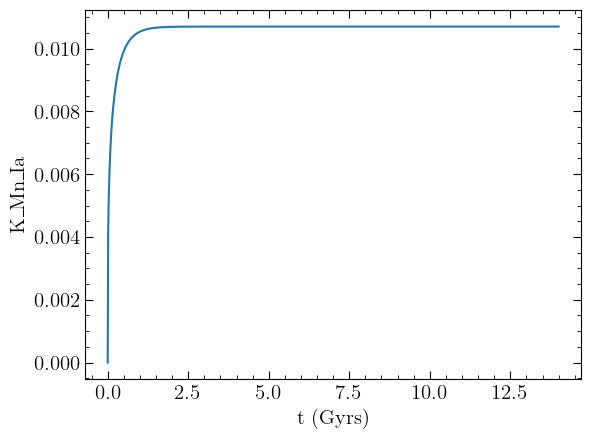

In [37]:
K_Mn_Ia = K_Mn_Ia_solar * get_F_Z_Zsolar(Z_O=Z_O_1, Z_O_solar=Z_O_solar, alpha_Ia=0.3)
plt.plot(t_array, K_Mn_Ia)
#plt.plot(t_array, K_Mn_Ia_solar * 10**(0.3 * gal1.O_H))
plt.xlabel('t (Gyrs)')
plt.ylabel('K_Mn_Ia')

# Now let's do the same thing for CC
$y_{Mn}^{cc} = y_{Mn}^{cc}(Z_{solar}) G(Z/Z_{solar})$

In [23]:
#Let's start with y_Mn_cc_solar
R_Ia_Mn = 1.97
alpha_cc = 0.17
alpha_Ia = 0.3
m_Fe_cc = gal1.m_Fe_cc_arr[0]

f_cc_Mn = 1 - f_Ia_Mn
f_cc_Fe = 1 - f_Ia_Fe
print(f"f_cc_Mn is {f_cc_Mn}")
#Now let's look at G(Z/Zsolar)
def get_G_Z_Zsolar(Z_O, Z_O_solar):
    return (Z_O/Z_O_solar)**alpha_cc


#method 1
y_Mn_cc_no_met_dep = m_Fe_cc * Z_Mn_solar/Z_Fe_solar * f_cc_Mn/f_cc_Fe
y_cc_met_dep_1 = y_Mn_cc_no_met_dep * get_G_Z_Zsolar(Z_O_1, Z_O_solar)

f_cc_Mn is 0.3367003367003367


In [ ]:
#method 2
p_cc_Mn = Z_Mn_solar/(1 + R_Ia_Mn)
y_Mn_cc_met_dep_2 = p_cc_Mn * get_G_Z_Zsolar(Z_O_1, Z_O_solar)

In [25]:
#method 3
y_cc_Mn = gal1.m_o_cc_arr[0] * (Z_Mn_solar/Z_O_solar) * 10**(alpha_cc * gal1.O_H)

In [35]:
Z_Fe_solar

0.0012

In [27]:
Z_Mn_numerical = gal1.compute_z_Mn(K_Mn_Ia=K_Mn_Ia, m_Mn_cc_arr=y_cc_Mn)

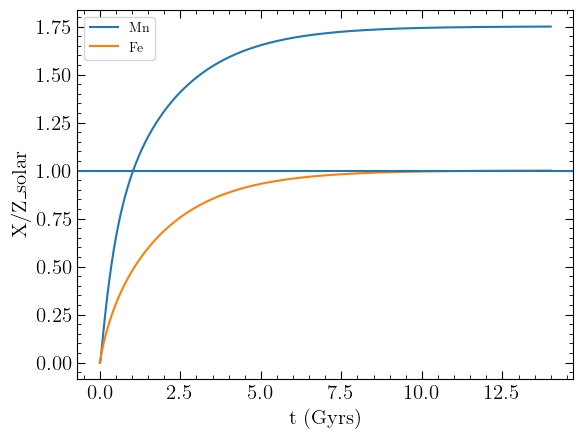

In [28]:
plt.plot(t_array, Z_Mn_numerical/Z_Mn_solar, label = 'Mn')
plt.plot(t_array, Z_Fe_1/Z_Fe_solar, label = 'Fe')
plt.axhline(1)

plt.xlabel('t (Gyrs)')
plt.ylabel('X/Z_solar')
plt.legend()

next steps: see how all of this would look like for Mn, if there was no metallicity dependance. And see how much yields would be in that case, if you were to match solar abundances. 

Make a new notebook, you have your code ready. play with R, and alphas, turn on and off ccsn and snia and see what it looks like